In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import pickle
import numpy as np
import matplotlib.pyplot as plt

from Data.loader import build_journey_table
from markov.builder import build_chains
from markov.dmd import (
    build_eigenvector_snapshot_matrix,
    build_chapter_eigenvector_snapshot_matrix,
    run_dmd, reconstruction_error, loo_reconstruction_error,
    deduplicate_conjugate_modes, plot_dmd_spectrum,
    icd10_chapter, group_codes_by_chapter,
)

In [ ]:
DATA_DIR    = Path("../Data/2026-ASA-DataFest-Data-Files")
MONTHLY_PKL = Path("../monthly_chains.pkl")
RANK        = None

In [ ]:
DATA_DIR     = Path("../Data/2026-ASA-DataFest-Data-Files")
QUARTERLY_PKL = Path("../monthly_chains.pkl")

K_EIGENVECTORS = 5    # top-k eigenvectors of each P(t) to use as DMD features
DMD_RANK       = None # None = auto (99% energy); set an int to override
MIN_QUARTERS   = 8    # skip GroupCodes with fewer observed quarters than this

In [ ]:
journey_table = build_journey_table(DATA_DIR)
print(f"Journey table: {len(journey_table):,} rows")

# Full 4-year chains give the canonical state space for every GroupCode
full_chains = build_chains(journey_table, min_transitions=50)
print(f"GroupCodes with full-dataset chains: {len(full_chains)}")

# Global state space = union of all specialties across all GroupCodes
state_space = sorted({s for chain in full_chains.values() for s in chain.states})
N = len(state_space)
print(f"Global state space: {N} specialties")

C:\Users\afjal\ASA-Datafest\Data\loader.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.read_csv(


Journey table: 6,364,363 rows
GroupCodes with full-dataset chains: 860
Global state space: 51 specialties


In [ ]:
journey_table = build_journey_table(DATA_DIR)
print(f"Journey table: {len(journey_table):,} rows")

# Full 4-year chains → canonical state space
full_chains = build_chains(journey_table, min_transitions=50)
print(f"GroupCodes with full-dataset chains: {len(full_chains)}")

state_space = sorted({s for chain in full_chains.values() for s in chain.states})
N = len(state_space)
print(f"Global state space: {N} specialties")

C:\Users\afjal\ASA-Datafest\Data\loader.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.read_csv(


Journey table: 6,364,363 rows
GroupCodes with full-dataset chains: 860
Global state space: 51 specialties


## 2 · Load quarterly chains

Run `monthly_chains.ipynb` first to produce `monthly_chains.pkl`.

In [ ]:
with open(QUARTERLY_PKL, "rb") as f:
    quarterly_chains = pickle.load(f)

periods = sorted(quarterly_chains.keys())
T_total = len(periods)
print(f"Loaded {T_total} quarters: {periods[0]} → {periods[-1]}")

Loaded 16 quarters: 2022Q1 → 2025Q4


## 3 · Group ICD-10 codes by chapter

Rather than pooling all diseases into a single aggregate, we run DMD separately
per ICD-10 chapter (e.g. Mental Health, Neoplasms, Circulatory).  Each chapter's
transition dynamics are clinically distinct and should not be mixed.

In [ ]:
all_codes = list(full_chains.keys())
chapters  = group_codes_by_chapter(all_codes)

print(f"{'Chapter':<30}  {'# codes':>7}")
print("-" * 42)
for ch, codes in sorted(chapters.items(), key=lambda x: -len(x[1])):
    print(f"{ch:<30}  {len(codes):>7}")

Chapter                         # codes
------------------------------------------
Neoplasms (C-D)                     113
Injury (S-T)                         88
Symptoms (R)                         72
Musculoskeletal (M)                  68
Factors (Z)                          56
Circulatory (I)                      55
Digestive (K)                        48
Skin (L)                             45
Genitourinary (N)                    45
Nervous System (G)                   41
Endocrine (E)                        38
Respiratory (J)                      38
Mental Health (F)                    34
Sensory (H)                          30
Pregnancy (O)                        29
Infectious (A-B)                     26
Congenital (Q)                       16
Other (W)                             8
Other (V)                             3
Other (Y)                             3
Other (U)                             2
Other (P)                             2


## 4 · Per-GroupCode eigenvector DMD — by chapter

For each ICD-10 chapter we:
1. Build the top-k eigenvector snapshot matrix for every GroupCode in that chapter
   (skipping codes with fewer than `MIN_QUARTERS` observed quarters).
2. Run SVD-based DMD with optDMD amplitude fitting (minimises global reconstruction error).
3. Deduplicate conjugate mode pairs (keep Im(λ) ≥ 0).
4. Compute in-sample reconstruction error **and** leave-one-out CV error.

The snapshot matrix has shape `(N × k, T)` — for N=51 states and k=5 this is
255 features × ≤16 quarters, far better conditioned than the old 2601 × 16.

In [ ]:
# Results store: chapter -> list of per-GroupCode DMD results
chapter_results: dict[str, list[dict]] = {}

lam_hdr = '|lambda|'
ang_hdr = 'angle(rad/qtr)'
per_hdr = 'period(qtrs)'
amp_hdr = '|amplitude|'
header  = f"{'Mode':>4}  {lam_hdr:>9}  {ang_hdr:>15}  {per_hdr:>13}  {amp_hdr:>12}"
divider = "-" * len(header)

for chapter_name, codes in sorted(chapters.items(), key=lambda x: -len(x[1])):
    results = []

    for code in sorted(codes):
        try:
            X_g, ev_mat, times_g = build_eigenvector_snapshot_matrix(
                quarterly_chains, code, state_space, k=K_EIGENVECTORS
            )
        except ValueError:
            continue

        if X_g.shape[1] < MIN_QUARTERS:
            continue

        try:
            modes_g, evals_g, amps_g, rank_g = run_dmd(X_g, rank=DMD_RANK)
        except Exception:
            continue

        modes_d, evals_d, amps_d = deduplicate_conjugate_modes(modes_g, evals_g, amps_g)

        err_in  = reconstruction_error(X_g, modes_g, evals_g, amps_g)
        try:
            err_loo = loo_reconstruction_error(X_g, rank=rank_g)
        except Exception:
            err_loo = float('nan')

        results.append({
            'code':       code,
            'X':          X_g,
            'ev_mat':     ev_mat,
            'times':      times_g,
            'modes':      modes_d,
            'eigenvalues': evals_d,
            'amplitudes': amps_d,
            'rank':       rank_g,
            'err_in':     err_in,
            'err_loo':    err_loo,
        })

    chapter_results[chapter_name] = results
    n_valid = len(results)
    if n_valid == 0:
        print(f"\n{chapter_name}: no GroupCodes with enough data — skipped")
        continue

    avg_err_in  = np.nanmean([r['err_in']  for r in results])
    avg_err_loo = np.nanmean([r['err_loo'] for r in results])
    print(f"\n{'='*70}")
    print(f"  {chapter_name}  ({n_valid} GroupCodes, avg in-sample err={avg_err_in:.3f}, LOO err={avg_err_loo:.3f})")
    print(f"{'='*70}")

    # Print top-3 GroupCodes by lowest LOO error (most predictable dynamics)
    sorted_r = sorted(results, key=lambda r: r['err_loo'])
    for r in sorted_r[:3]:
        print(f"\n  -- {r['code']}  T={X_g.shape[1]} qtrs  rank={r['rank']}"
              f"  in-err={r['err_in']:.3f}  LOO-err={r['err_loo']:.3f}")
        print(f"  {header}")
        print(f"  {divider}")
        for i, (ev, amp) in enumerate(zip(r['eigenvalues'], r['amplitudes'])):
            angle  = np.angle(ev)
            period = f"{abs(2*np.pi/angle):>13.1f}" if abs(angle) > 1e-6 else "     monotone"
            print(f"  {i+1:>4}  {abs(ev):>9.4f}  {angle:>15.4f}  {period}  {abs(amp):>12.4f}")


  Neoplasms (C-D)  (85 GroupCodes, avg in-sample err=0.671, LOO err=0.946)

  -- C93  T=14 qtrs  rank=9  in-err=0.524  LOO-err=0.605
  Mode   |lambda|   angle(rad/qtr)   period(qtrs)   |amplitude|
  -------------------------------------------------------------
     1     1.0000           0.0000       monotone        2.0620
     2     0.7973           0.0000       monotone        4.1587
     3     0.6363           2.0936            3.0        0.9685
     4     0.4029           3.1416            2.0        5.3698
     5     0.2361           0.0000       monotone       13.5810
     6     0.1594           3.1416            2.0       26.1865

  -- C37  T=14 qtrs  rank=5  in-err=0.504  LOO-err=0.615
  Mode   |lambda|   angle(rad/qtr)   period(qtrs)   |amplitude|
  -------------------------------------------------------------
     1     0.9652           0.0000       monotone        2.2511
     2     0.5170           3.1416            2.0        0.5502
     3     0.5003           1.8218      

## 5 · Chapter-level comparison

Compare average in-sample and LOO reconstruction errors across ICD-10 chapters.
Chapters with low LOO error have more temporally predictable department-flow dynamics.

## 6 · Eigenvalue spectra per chapter

For each chapter, show the eigenvalue spectrum of the GroupCode with the lowest
LOO CV error (most predictable dynamics) together with the universal eigenvalue
scatter for all GroupCodes in that chapter.

**Inside** unit circle = decaying mode.  **On** = persistent/oscillatory.
**Outside** = growing trend (do not extrapolate far).

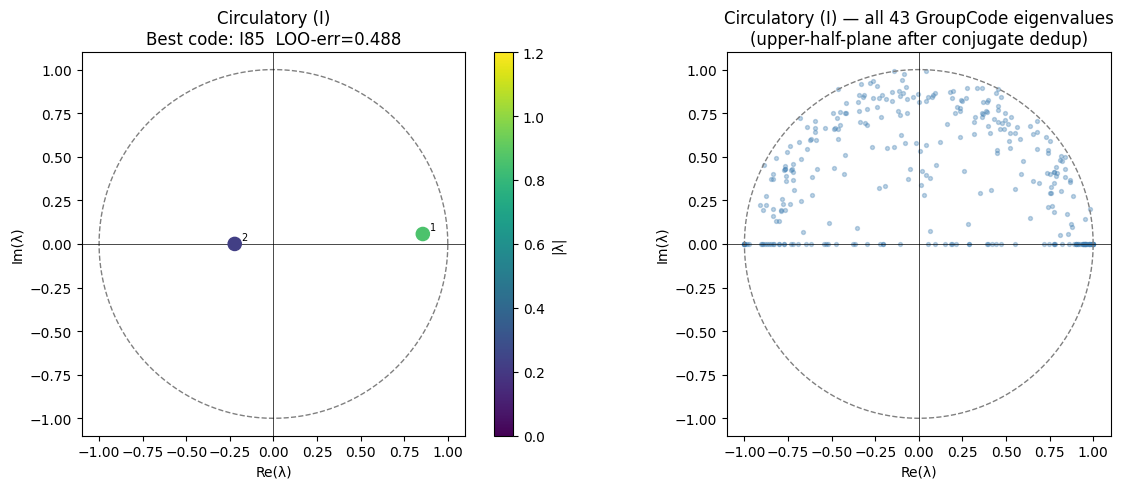

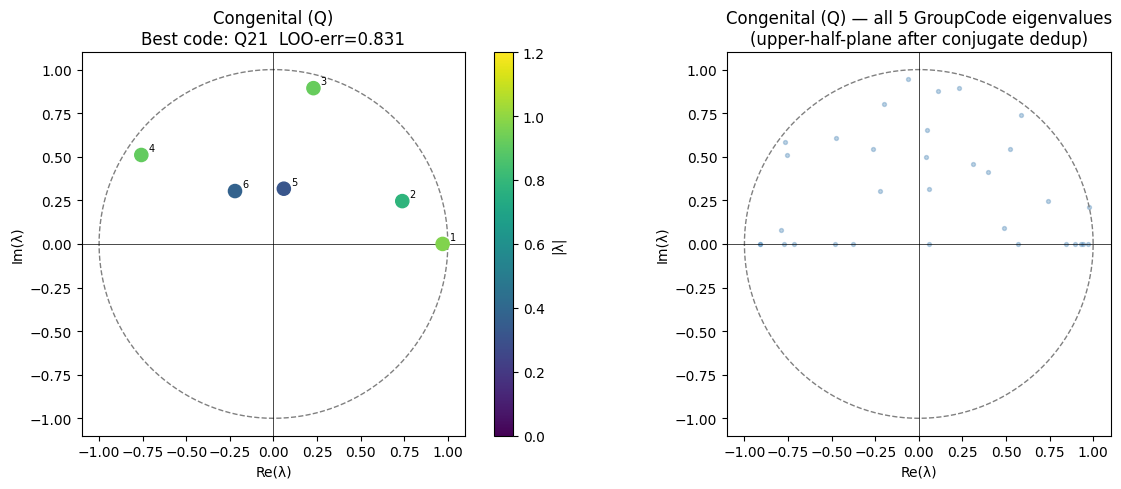

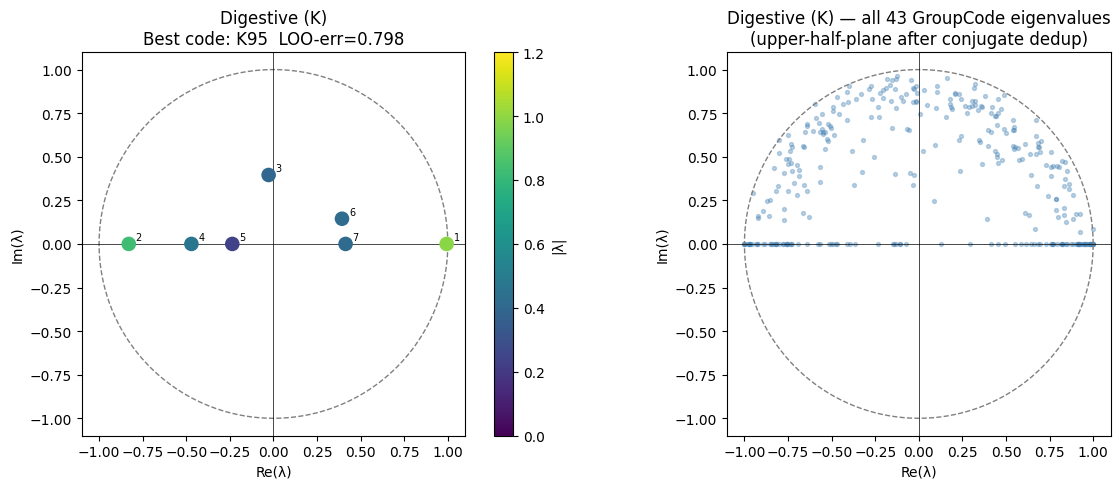

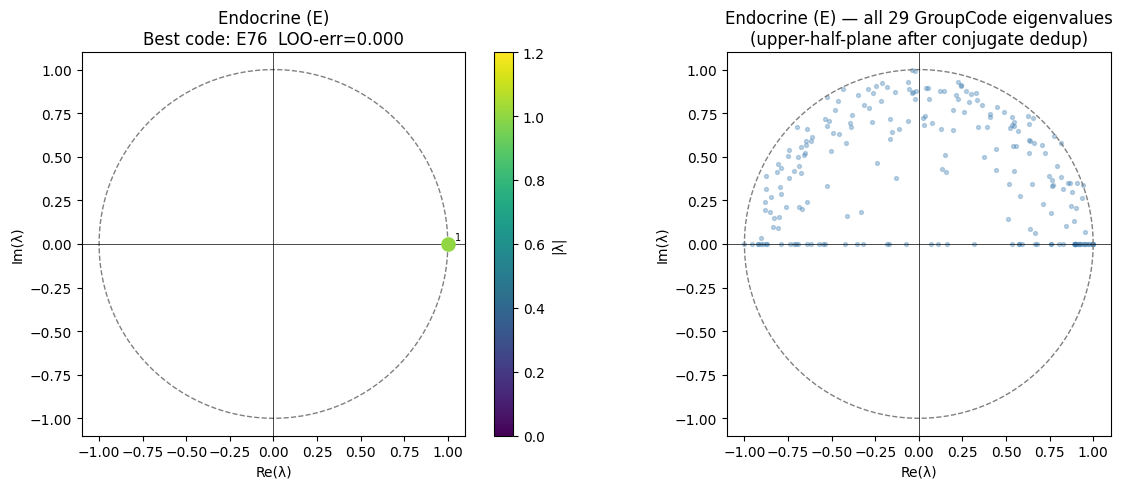

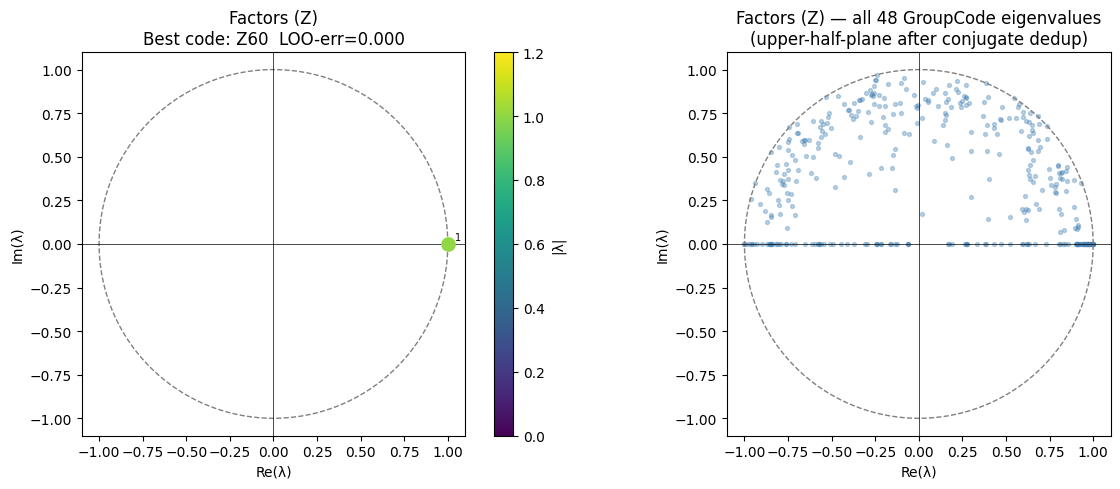

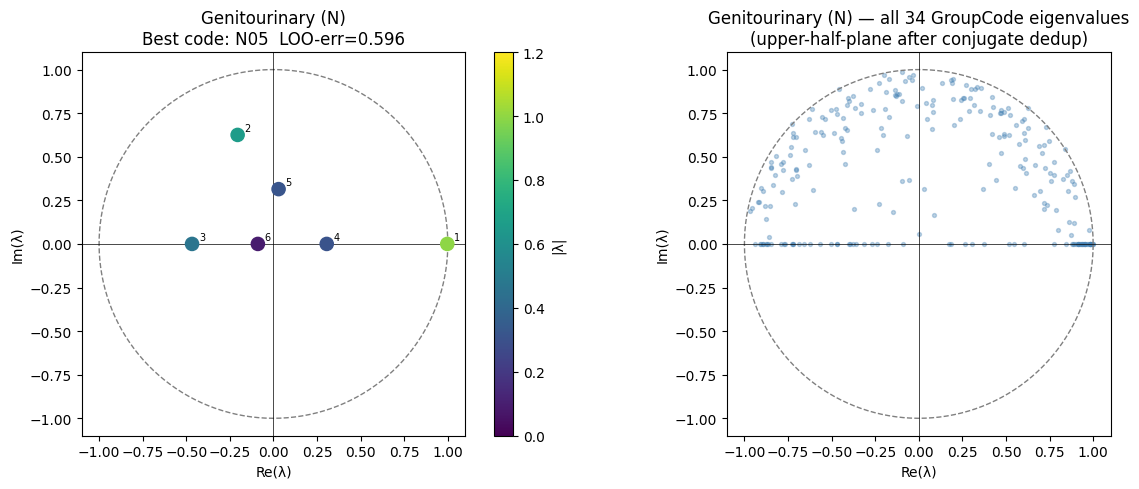

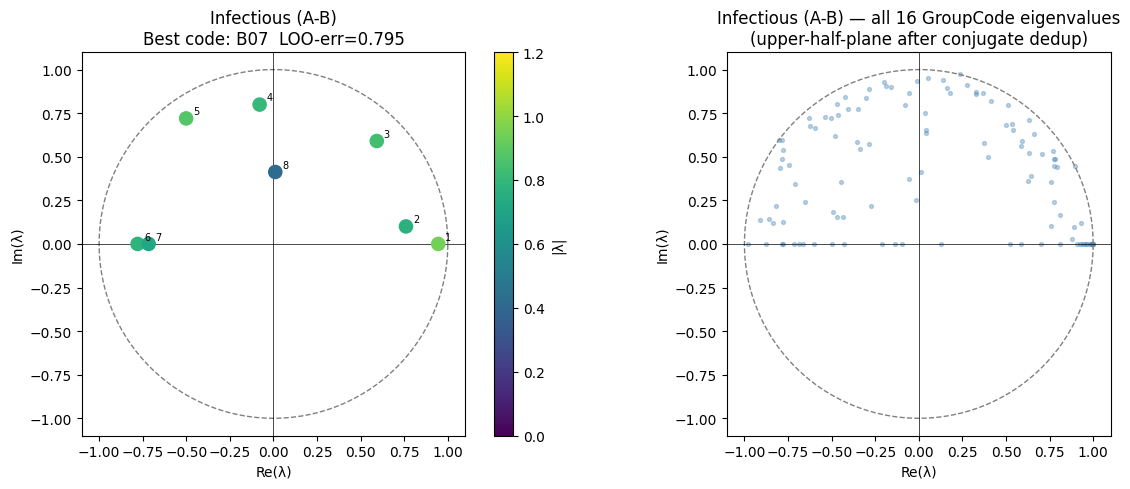

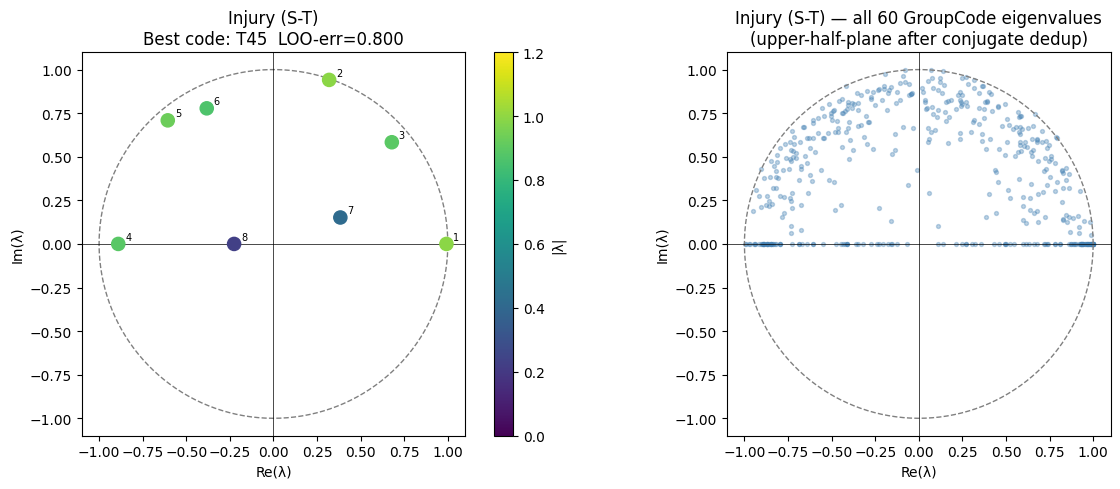

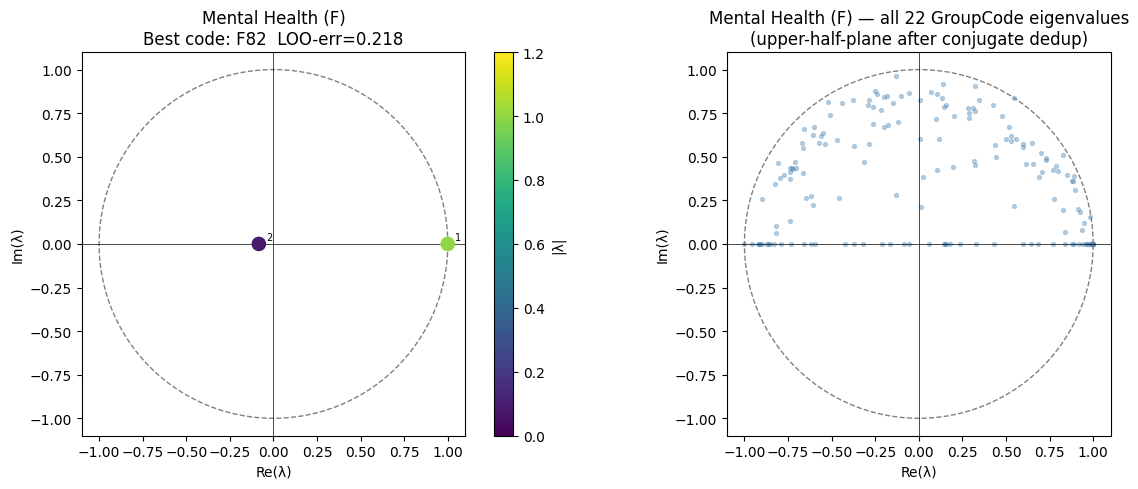

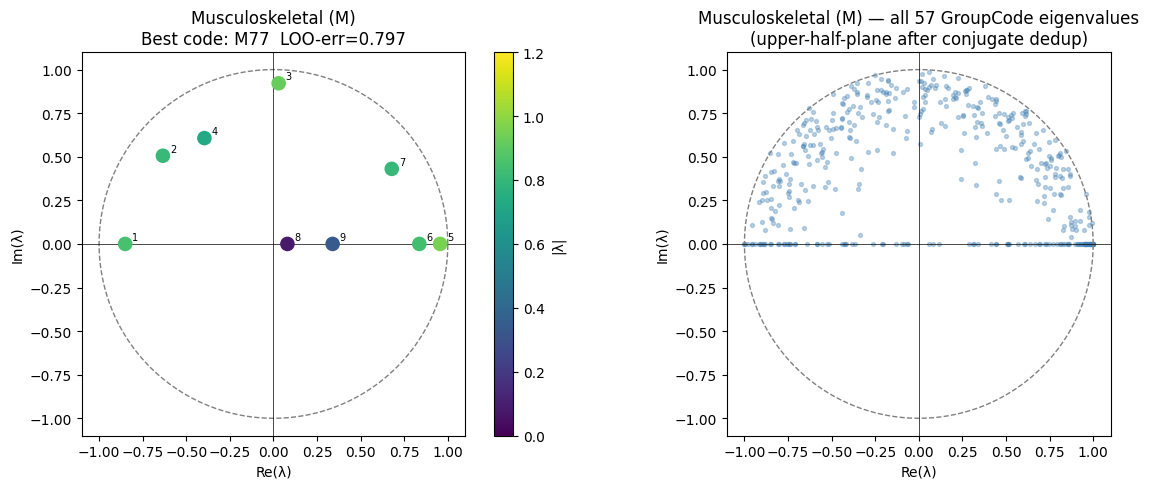

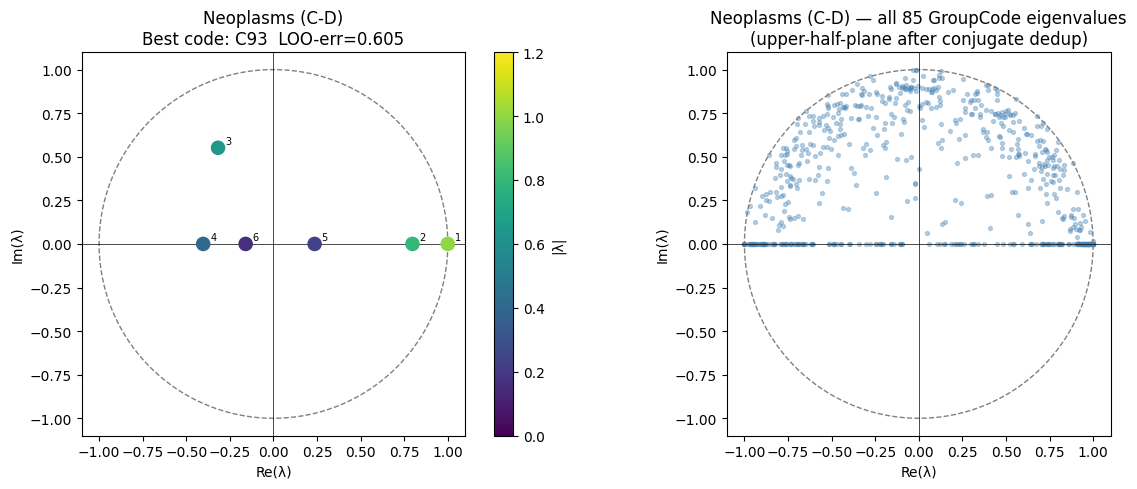

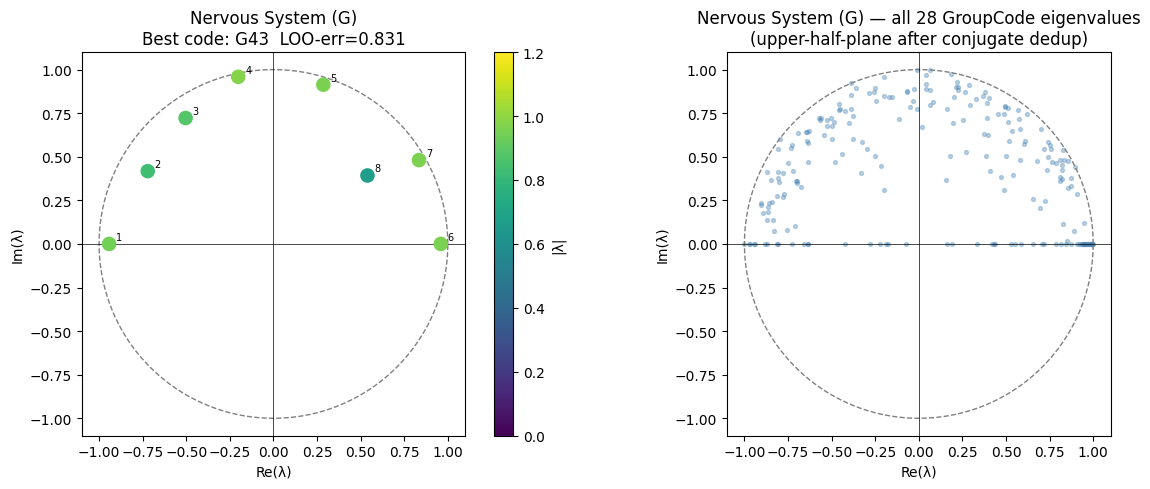

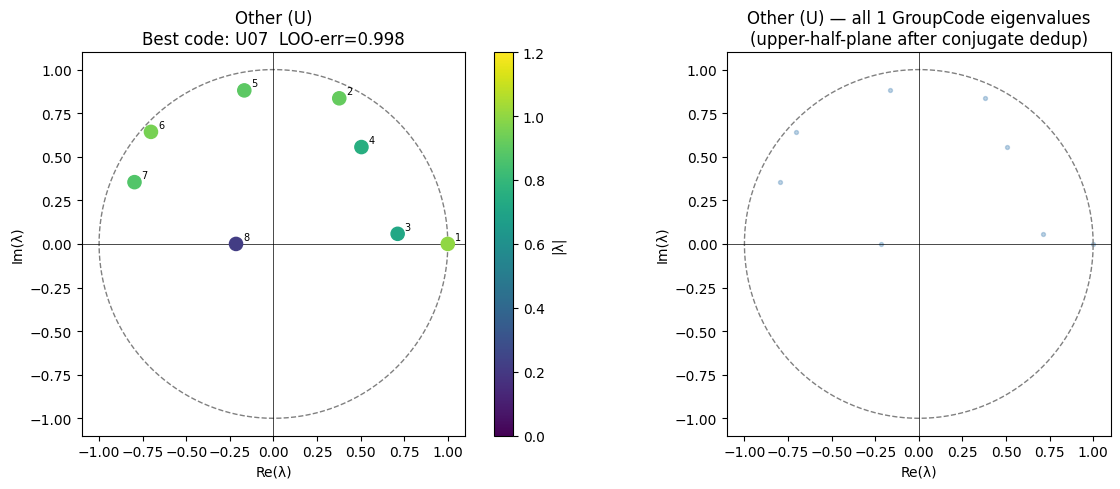

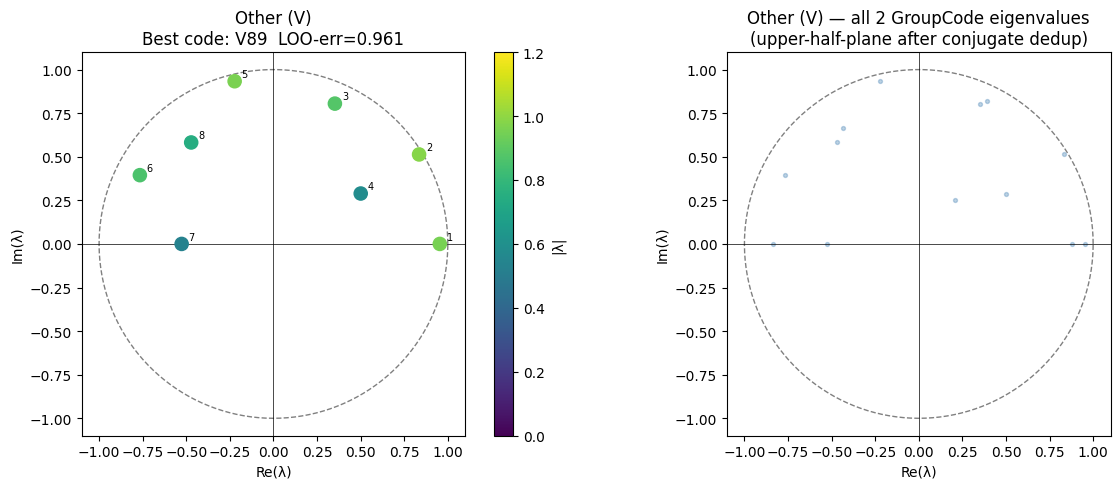

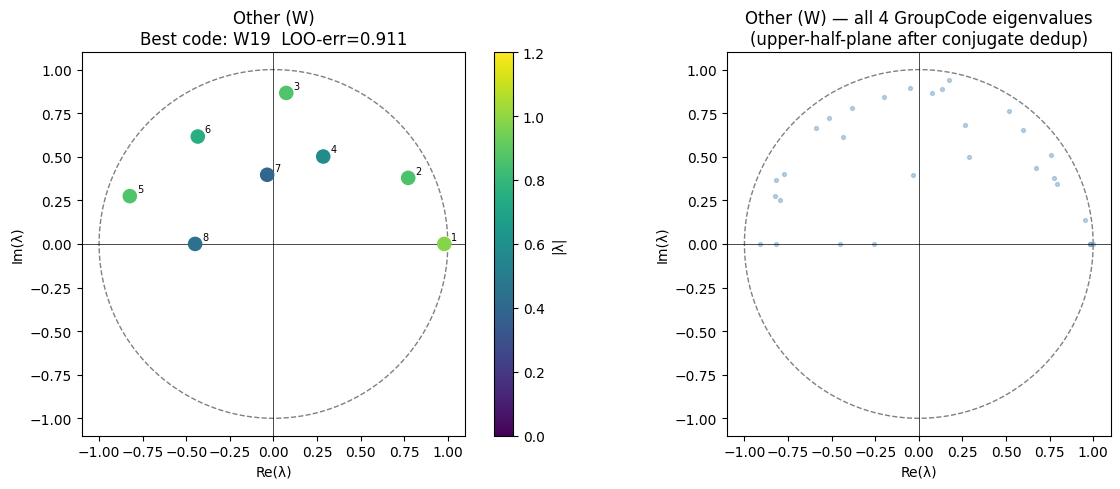

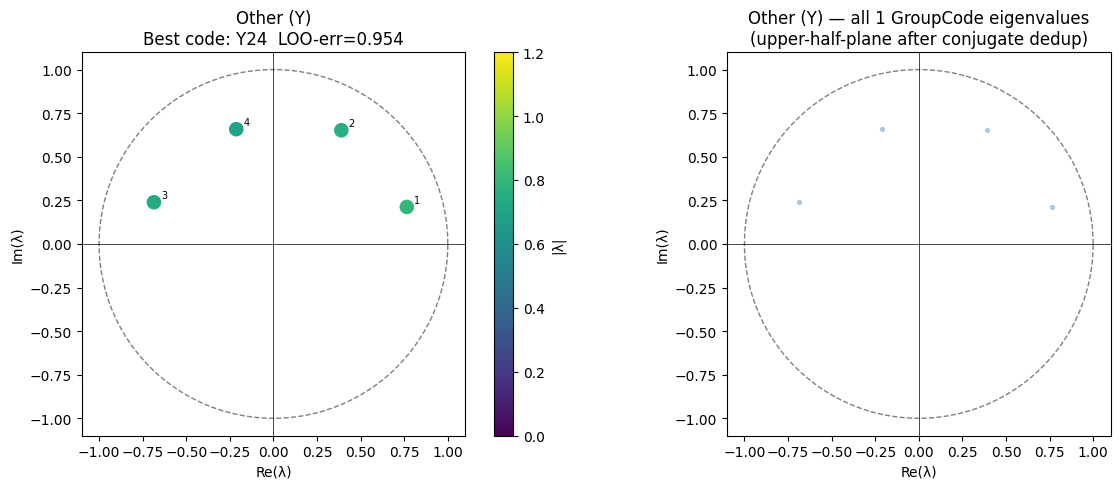

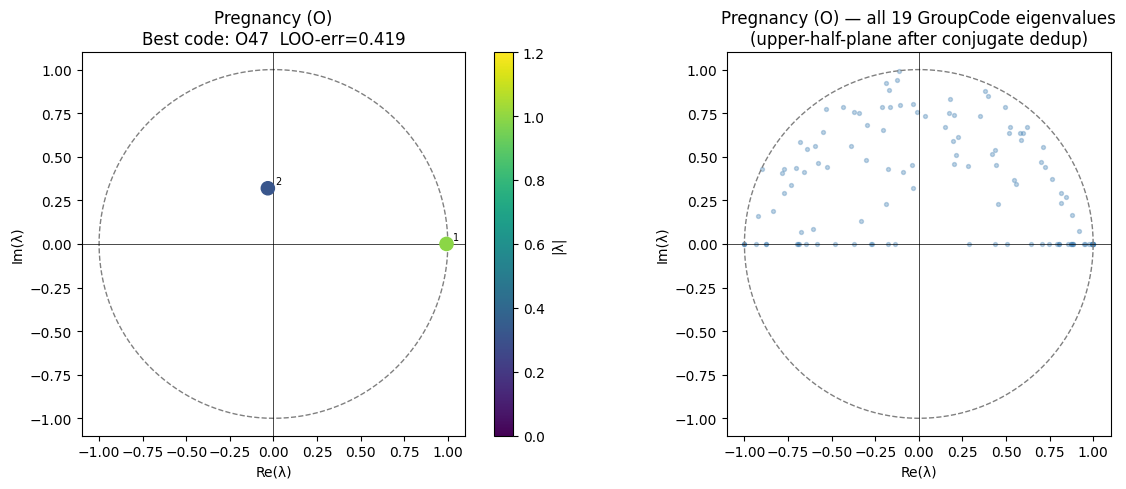

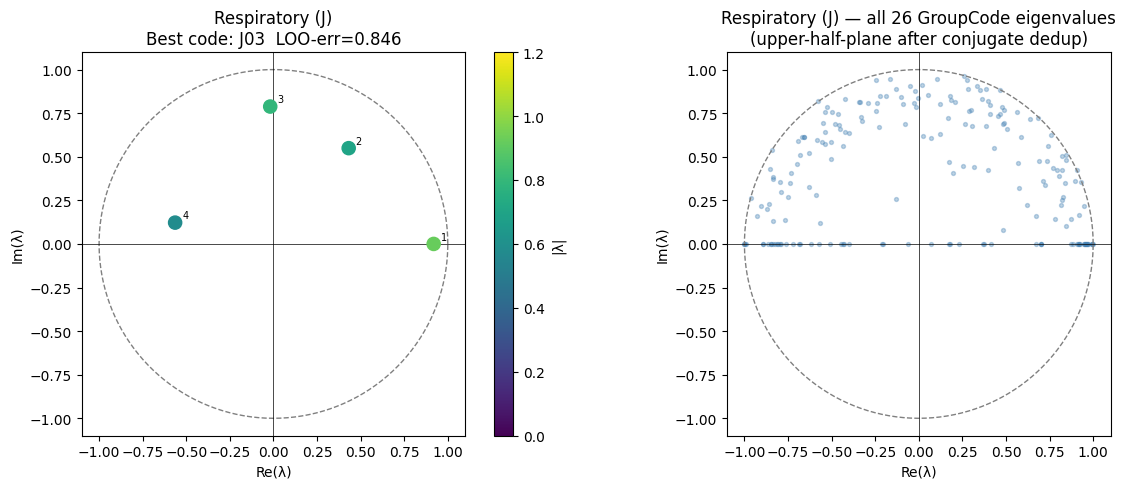

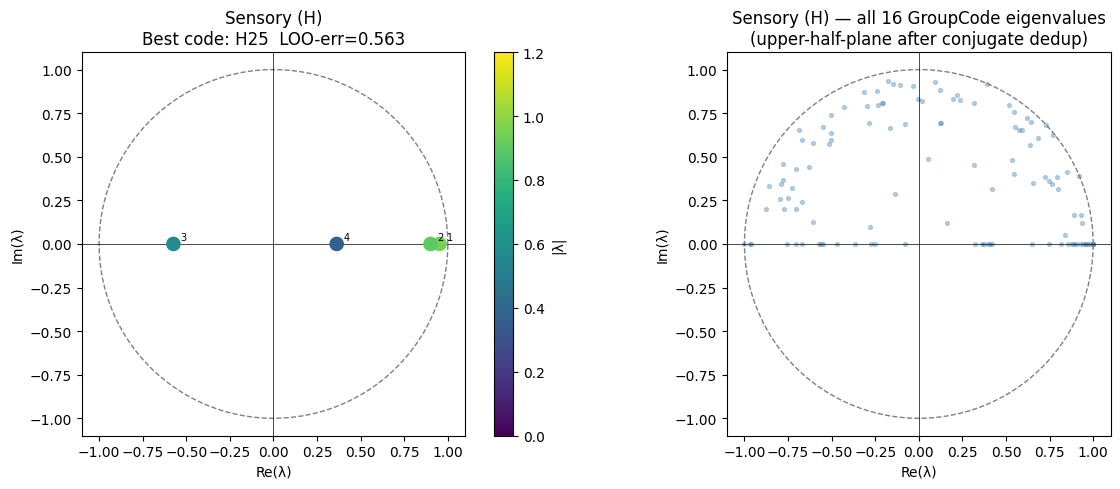

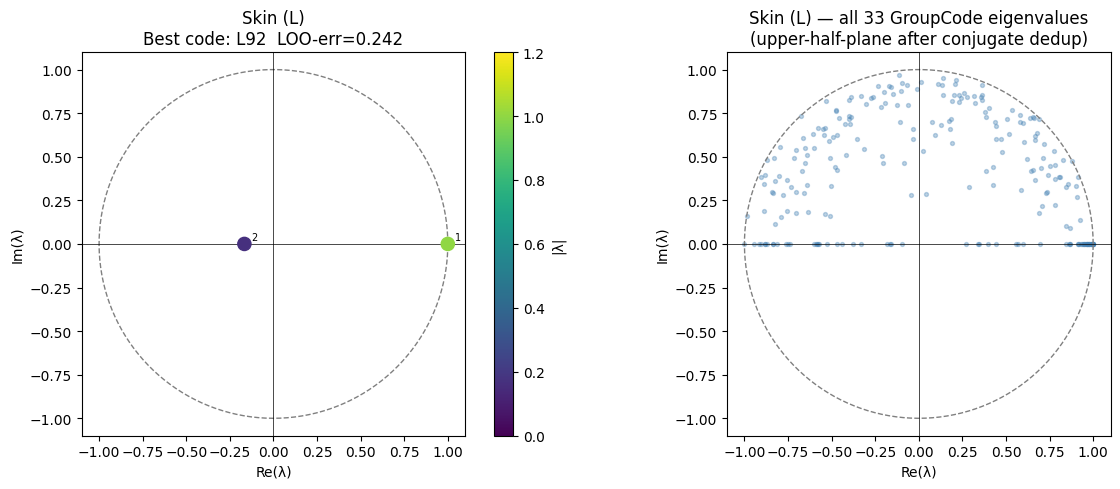

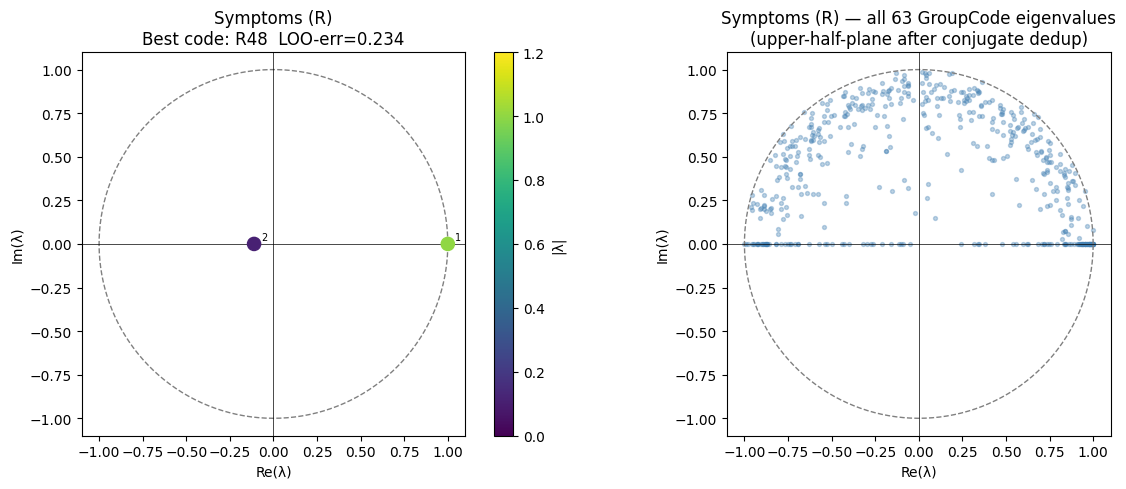

In [ ]:
for chapter_name, results in sorted(chapter_results.items()):
    if not results:
        continue

    # Best GroupCode = lowest LOO error
    best = min(results, key=lambda r: r['err_loo'])

    # Collect all eigenvalues across this chapter for scatter
    all_eigs_ch = np.concatenate([r['eigenvalues'] for r in results])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    theta = np.linspace(0, 2 * np.pi, 300)

    # Left: best GroupCode spectrum
    ax = axes[0]
    ax.plot(np.cos(theta), np.sin(theta), color='grey', lw=1, ls='--')
    mags = np.abs(best['eigenvalues'])
    sc   = ax.scatter(best['eigenvalues'].real, best['eigenvalues'].imag,
                      c=mags, cmap='viridis', s=90, zorder=3, vmin=0, vmax=1.2)
    plt.colorbar(sc, ax=ax, label='|λ|')
    for i, ev in enumerate(best['eigenvalues']):
        ax.annotate(str(i+1), (ev.real, ev.imag), textcoords='offset points',
                    xytext=(5, 3), fontsize=7)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('Re(λ)'); ax.set_ylabel('Im(λ)')
    ax.set_title(f"{chapter_name}\nBest code: {best['code']}  LOO-err={best['err_loo']:.3f}")

    # Right: all GroupCode eigenvalues in chapter
    ax2 = axes[1]
    ax2.plot(np.cos(theta), np.sin(theta), color='grey', lw=1, ls='--')
    ax2.scatter(all_eigs_ch.real, all_eigs_ch.imag, s=8, alpha=0.35, color='steelblue')
    ax2.axhline(0, color='k', lw=0.5); ax2.axvline(0, color='k', lw=0.5)
    ax2.set_aspect('equal')
    ax2.set_xlabel('Re(λ)'); ax2.set_ylabel('Im(λ)')
    ax2.set_title(f"{chapter_name} — all {len(results)} GroupCode eigenvalues\n"
                  f"(upper-half-plane after conjugate dedup)")

    plt.tight_layout()
    plt.show()

## 7 · Markov eigenvalue trajectories

Track how the top-k eigenvalues of P(t) change over time for the best GroupCode
in each chapter.  A flat line = stationary dynamics; drift = genuine temporal change.

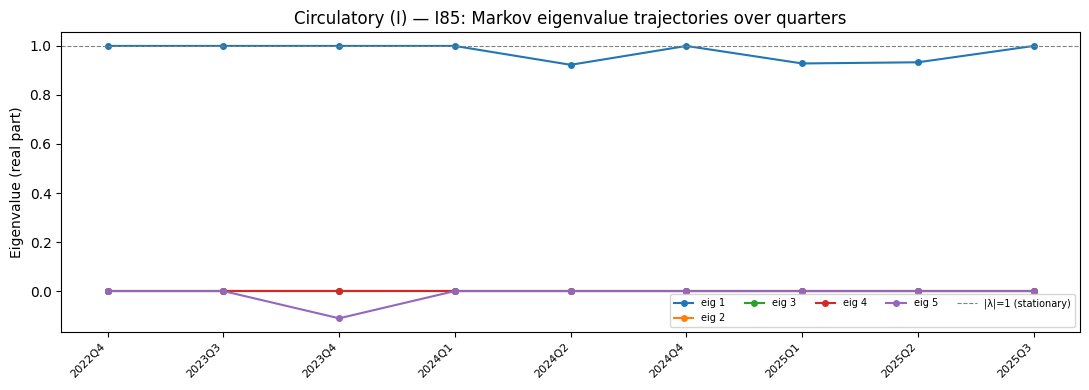

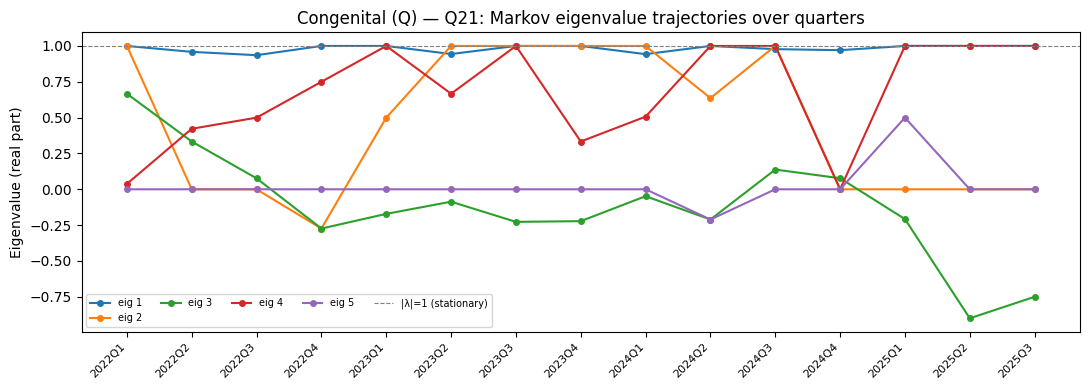

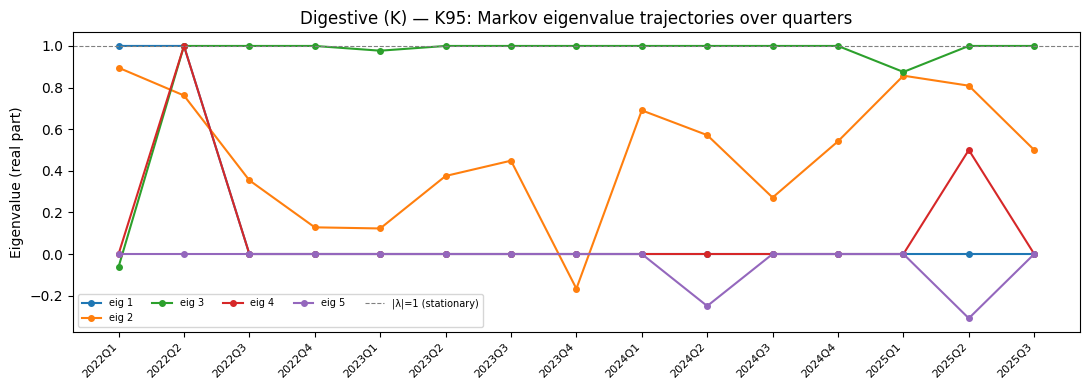

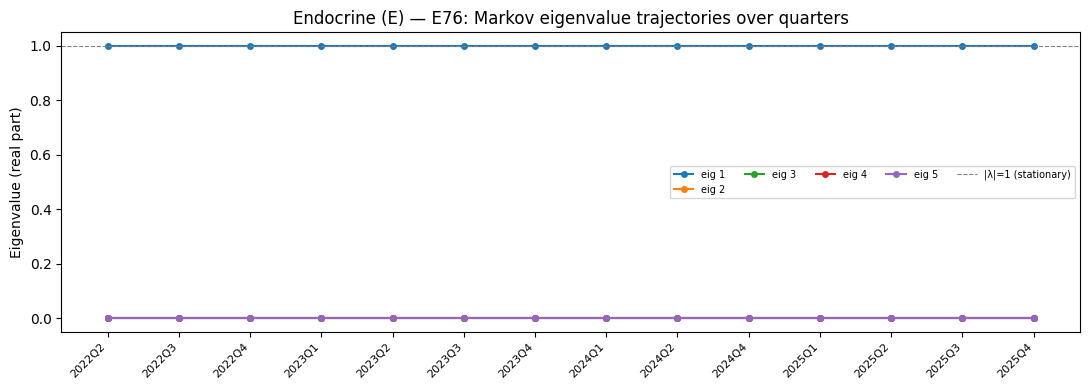

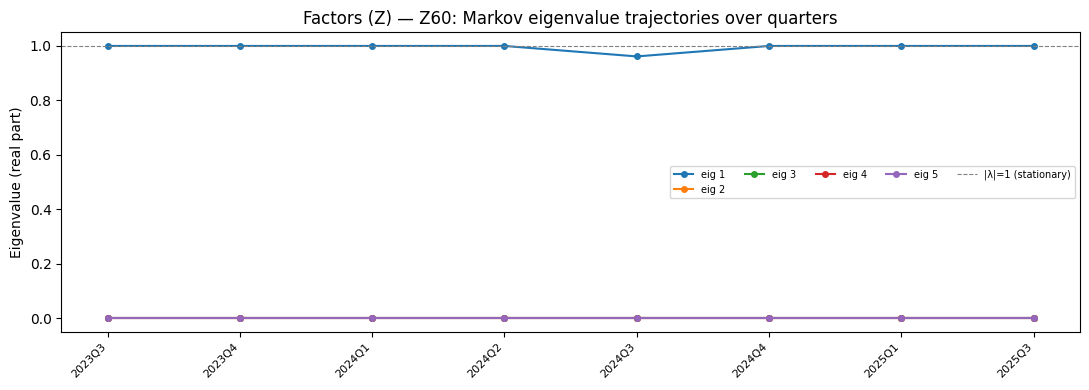

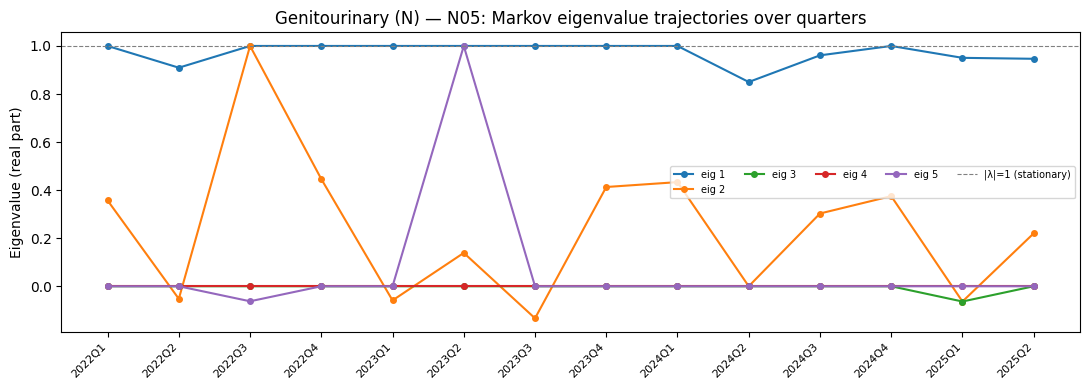

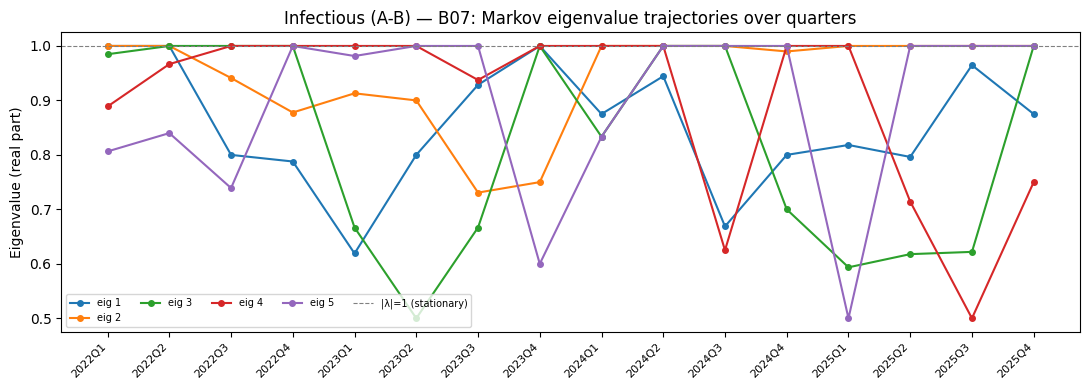

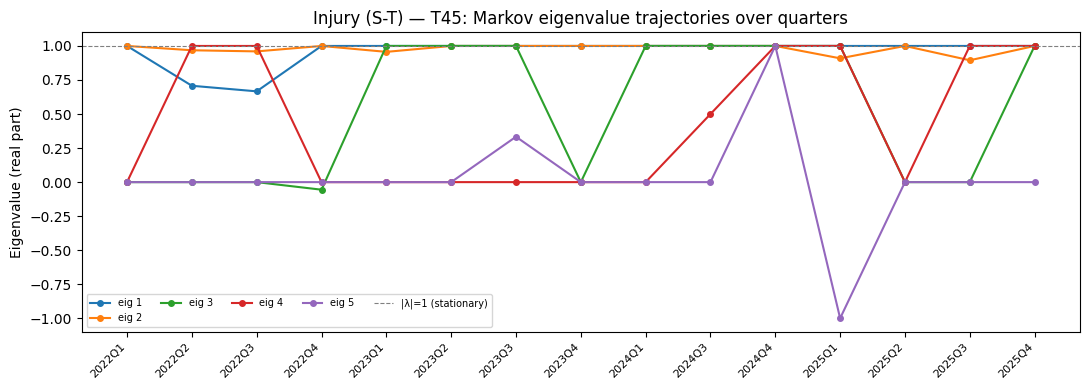

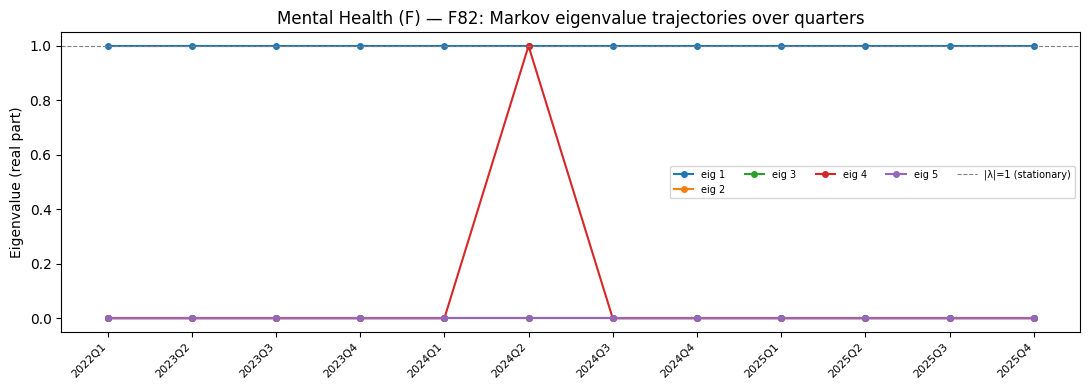

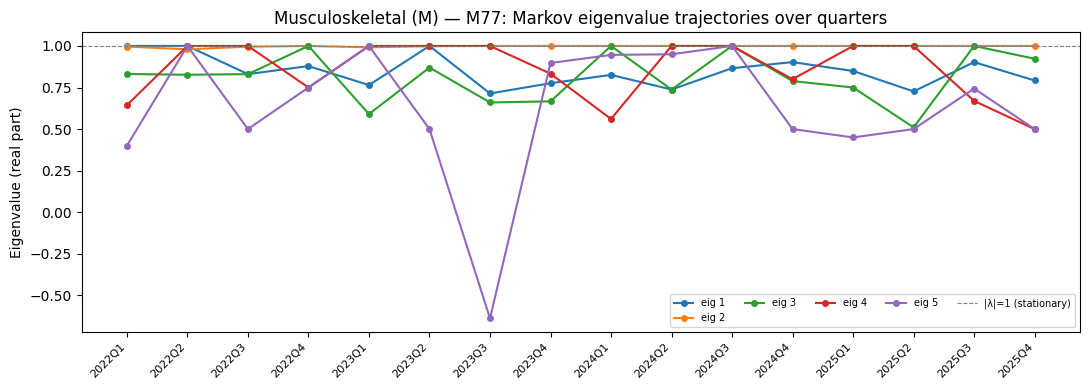

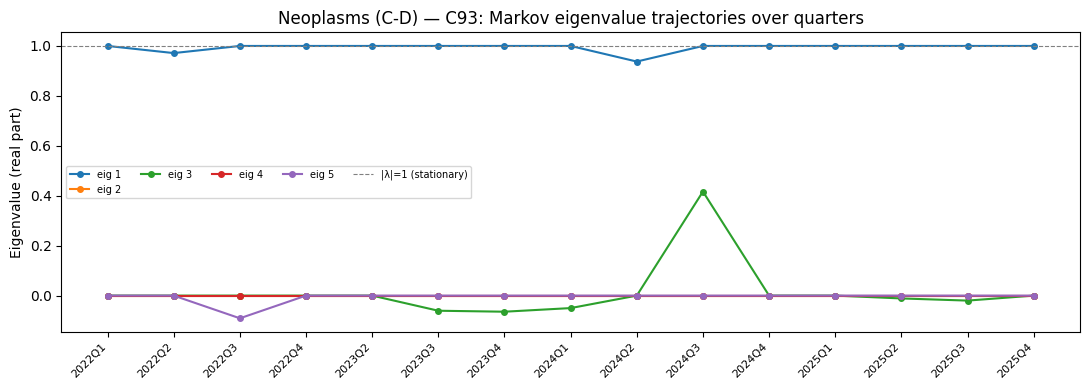

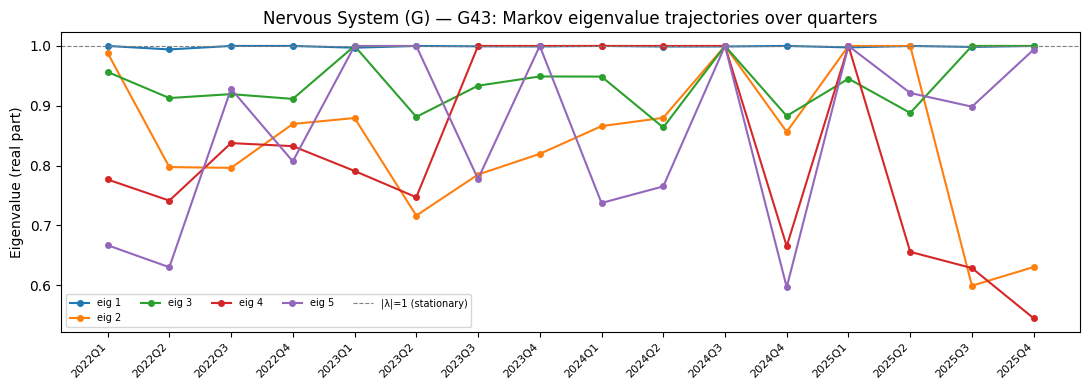

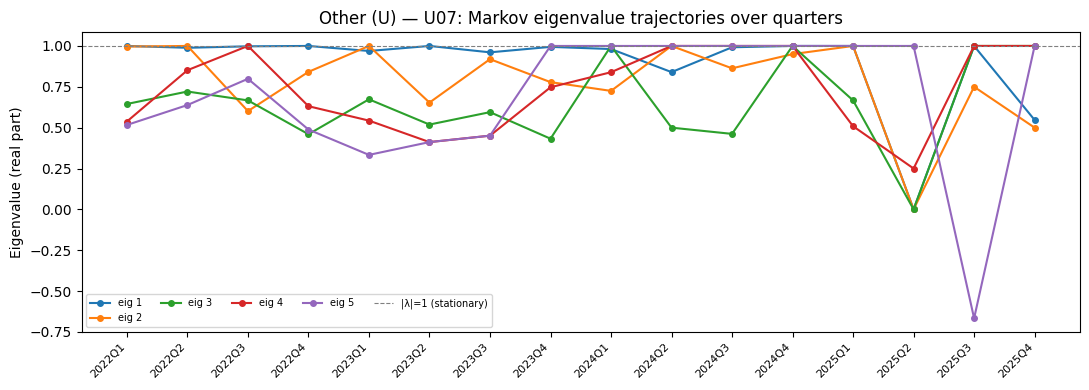

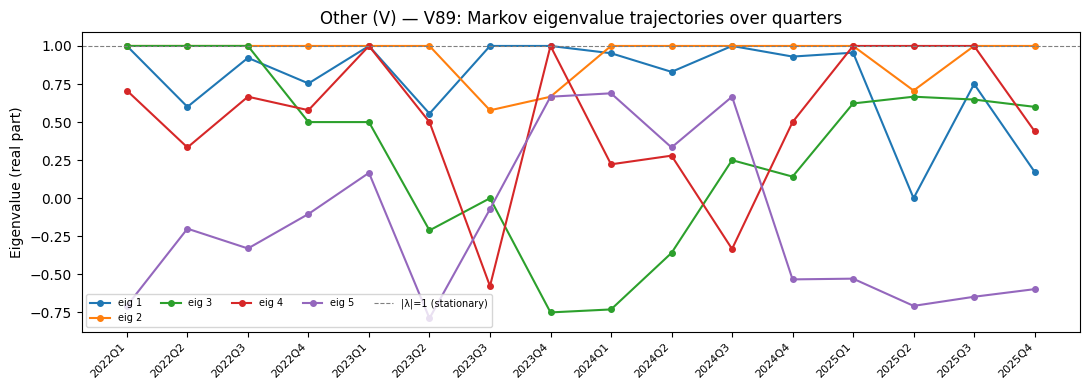

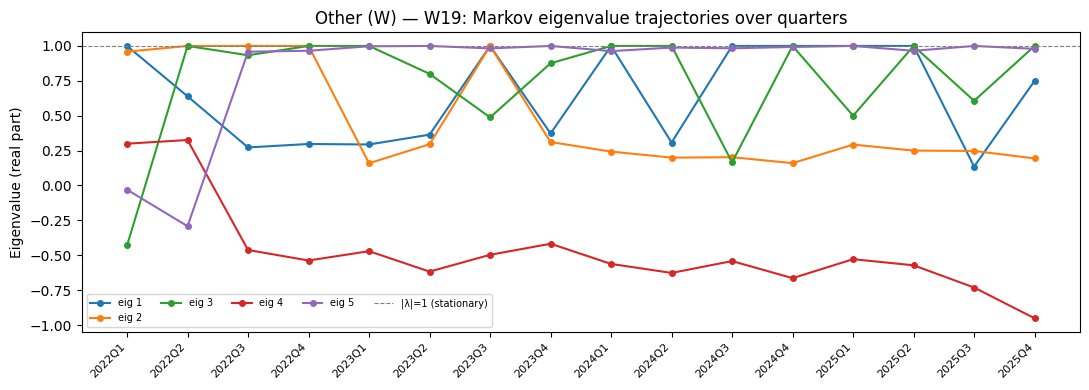

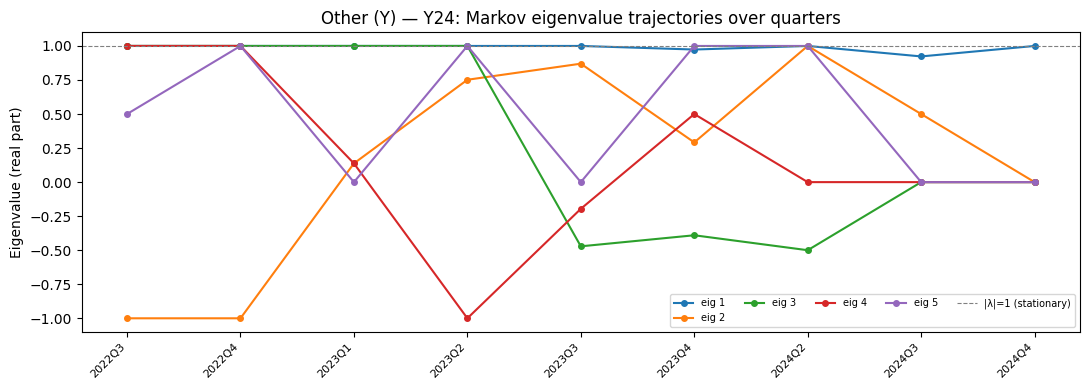

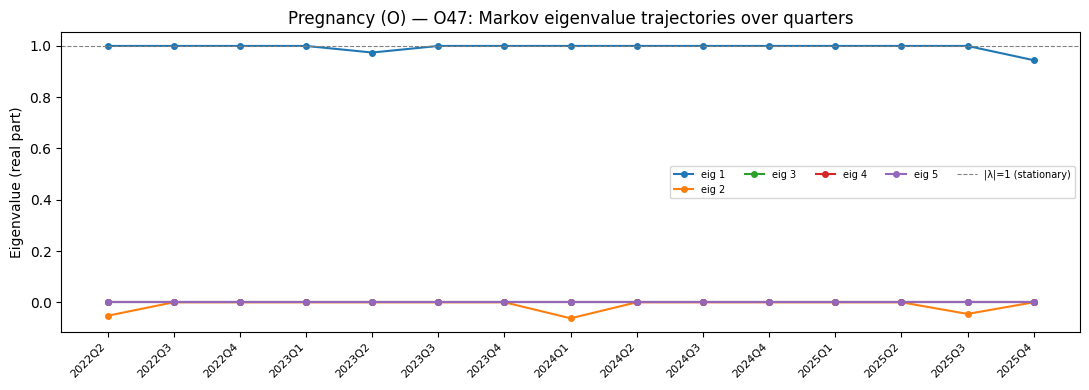

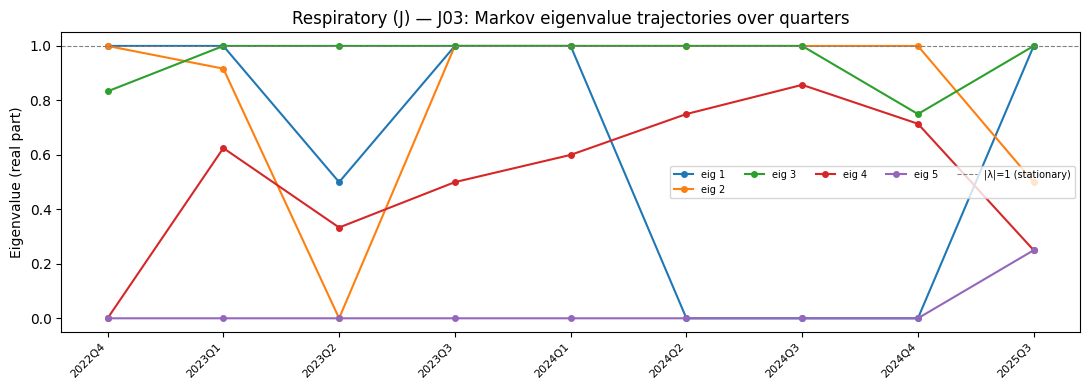

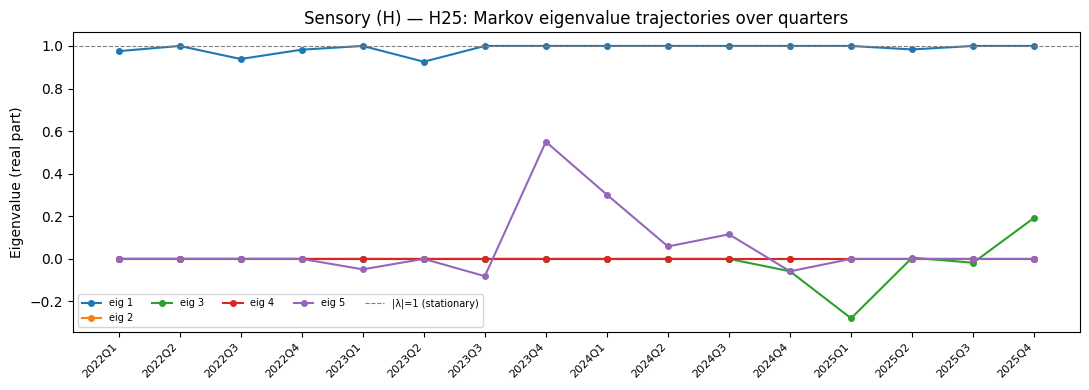

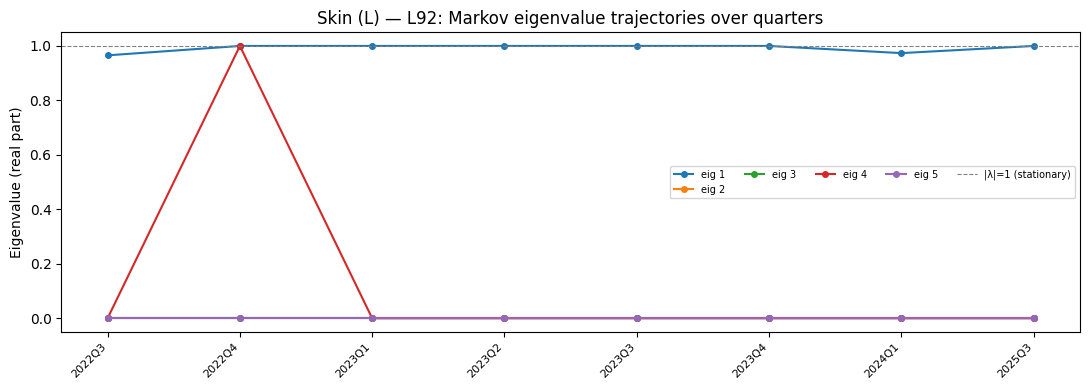

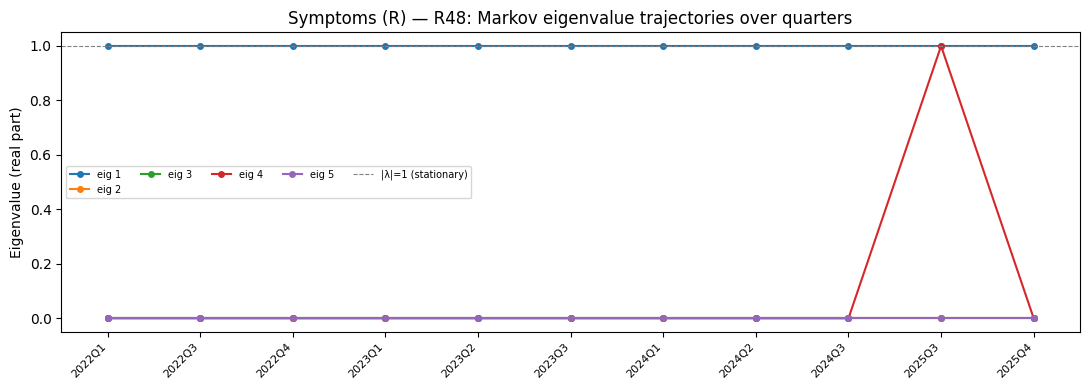

In [ ]:
for chapter_name, results in sorted(chapter_results.items()):
    if not results:
        continue

    best = min(results, key=lambda r: r['err_loo'])
    ev_mat = best['ev_mat']    # (k, T)
    times  = best['times']
    k_plot = ev_mat.shape[0]

    fig, ax = plt.subplots(figsize=(11, 4))
    for j in range(k_plot):
        ax.plot(range(len(times)), ev_mat[j], marker='o', markersize=4,
                linewidth=1.5, label=f'eig {j+1}')

    ax.axhline(1.0, color='grey', lw=0.8, ls='--', label='|λ|=1 (stationary)')
    ax.set_xticks(range(len(times)))
    ax.set_xticklabels(times, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Eigenvalue (real part)')
    ax.set_title(f"{chapter_name} — {best['code']}: Markov eigenvalue trajectories over quarters")
    ax.legend(fontsize=7, ncol=k_plot)
    plt.tight_layout()
    plt.show()

In [ ]:
#Yash's code to add
print("Mode 1 (baseline):")
print(modes[:, 0])  # This is the REAL mode vector


# Print actual amplitude
print(f"Amplitude: {amplitudes[0]}")  # This is REAL


# Print actual eigenvalue
print(f"Eigenvalue: {eigenvalues[0]}")  # This is REAL


def extract_mode_meaning(mode_vector, state_space, N):
   """
   Convert a mode vector to a readable transition matrix
   showing which transitions STRENGTHEN/WEAKEN in this mode
   """
  
   # Reshape mode back to N×N matrix
   matrix = mode_vector.real.reshape(N, N)
  
   # Convert to DataFrame for readability
   df = pd.DataFrame(
       matrix,
       index=state_space,
       columns=state_space
   )
  
   print("Mode pattern (real part):")
   print(df)
   print("\nInterpretation:")
   print("Positive values: transitions that STRENGTHEN in this mode")
   print("Negative values: transitions that WEAKEN in this mode")
   print("Larger magnitude: stronger effect")
  
   return df


# Usage:
for i, mode in enumerate(modes.T):
   print(f"\n{'='*70}")
   print(f"MODE {i+1}")
   print(f"{'='*70}")
   extract_mode_meaning(mode, state_space, N)